In [1]:
# importamos las librerías 

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [2]:
#abrimos df
df_clientes = pd.read_csv("clientes_limpio.csv")

In [51]:
df_info_vuelos = pd.read_csv("vuelos_limpio.csv")

In [53]:
df_final = pd.read_csv("info_unida.csv")

In [4]:
media_salary = round(df_clientes["Salary"].mean(),2)# calculamos la media redondeando decimales
print(media_salary)

79429.57


In [5]:
mediana_salary = round(df_clientes["Salary"].median(),2) #mediana 
print(mediana_salary)

79429.57


In [ ]:
media_mediana_salario = df_clientes["Salary"].agg(["mean","median"])
media_mediana_salario

mean      79429.572643
median    79429.572643
Name: Salary, dtype: float64

In [7]:
df_clientes["Salary"].std() #desviacion estandar

np.float64(29986.16541812082)

In [15]:
df_clientes["Salary"].agg(["min", "max"])#para ver el salario minimo y el maximo

min     15609.0
max    407228.0
Name: Salary, dtype: float64

In [22]:
df_clientes[df_clientes["Salary"] > 120000]

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Salary,Cancellation Year,Cancellation Month
15,205785,Canada,Ontario,Toronto,M2M 6J7,Male,Master,Married,Star,3873.65,Standard,2016,8,128118.0,2016,7
16,735304,Canada,Alberta,Edmonton,T3G 6Y6,Female,Master,Married,Star,3873.65,Standard,2016,12,128118.0,2016,7
55,878633,Canada,Ontario,Trenton,K8V 4B2,Female,Doctor,Married,Star,3936.79,Standard,2013,12,163974.0,2016,7
60,124678,Canada,Nova Scotia,Halifax,B3J 9S2,Male,Doctor,Married,Star,3954.34,Standard,2013,6,152955.0,2016,7
61,186015,Canada,British Columbia,Vancouver,V6E 3Z3,Male,Doctor,Married,Star,3954.34,Standard,2015,9,152955.0,2016,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16562,961961,Canada,Ontario,Kingston,M9K 2P4,Female,Doctor,Married,Star,26197.41,Standard,2014,8,154475.0,2016,7
16586,579424,Canada,British Columbia,Vancouver,V6E 3Z3,Female,Doctor,Married,Star,27564.74,Standard,2017,7,254724.0,2016,7
16645,265383,Canada,New Brunswick,Fredericton,E3B 2H2,Male,Doctor,Married,Star,31803.31,Standard,2017,3,245263.0,2016,7
16646,817714,Canada,Quebec,Montreal,H4G 3T4,Male,Doctor,Married,Star,31803.31,Standard,2013,6,245263.0,2016,7


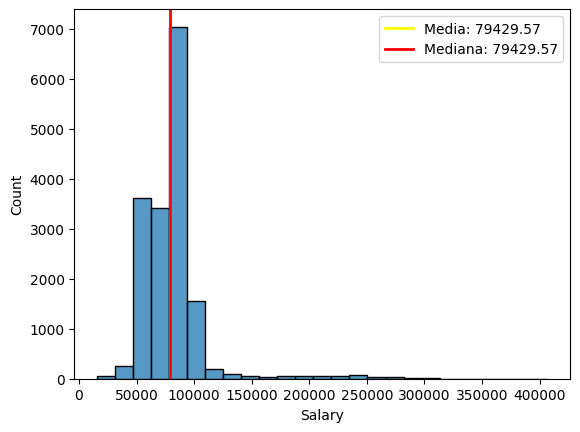

In [8]:
sns.histplot(data=df_clientes, x= "Salary", bins=25);# para que nos ayude a entender los datos 
#esta bien dibujar un histograma
plt.axvline(media_salary, color = "yellow", linestyle = "-", linewidth = 2, label = f"Media: {media_salary}")
plt.axvline(mediana_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Mediana: {mediana_salary}")
plt.legend(); #con esto dibujamos las dos lineas de media y mediana

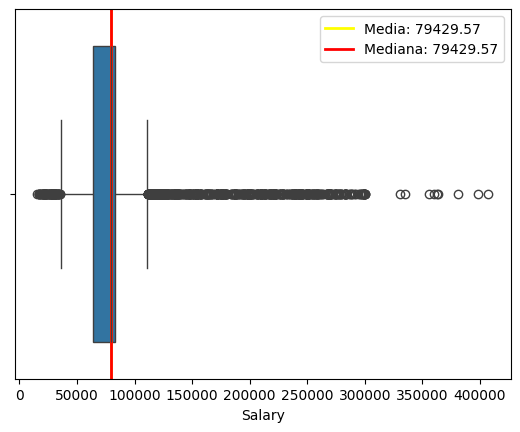

In [24]:
sns.boxplot(data=df_clientes, x = "Salary")
plt.axvline(media_salary, color = "yellow", linestyle = "-", linewidth = 2, label = f"Media: {media_salary}")
plt.axvline(mediana_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Mediana: {mediana_salary}")
plt.legend();
#hacemos un boxplot con las lineas de media y mediana

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Bachelor'),
  Text(1, 0, 'College'),
  Text(2, 0, 'Master'),
  Text(3, 0, 'High School or Below'),
  Text(4, 0, 'Doctor')])

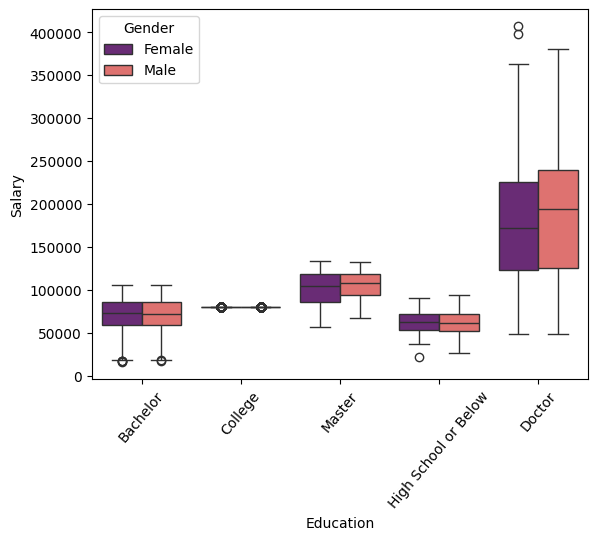

In [33]:
sns.boxplot(data=df_clientes, x="Education", y="Salary", hue="Gender", palette="magma")
plt.xticks(rotation=50)

Interpretación: Cuando la media y la mediana son iguales, significa que la distribución de salarios es muy simétrica no hay grupos extremos de gente.Tienes un grupo de clientes con niveles adquisitivos muy variados, lo cual es real en una base de datos de una aerolínea. en casi todos los grupos de estudios hay el mismo numero de mujeres que de hombres.

In [10]:
# ¿Cuál es la ciudad con más clientes?
ciudad_frecuente = df_clientes["City"].mode()[0]
ciudad_frecuente

'Toronto'

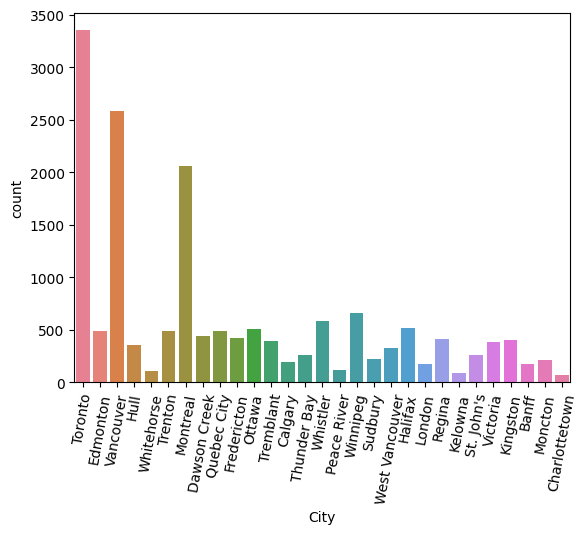

In [11]:
sns.countplot(data=df_clientes, x="City", hue="City");
plt.xticks(rotation=80)
plt.show() #hacemos un countplot para variables categoricas

Interpretacion: Podemos ver que la cuidad que mas clientes tienen son Toronto,Vancouber,Montreal que  son las 3 ciudades mas grandes y con mas habitantes.

In [12]:
df_clientes.columns

Index(['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code',
       'Gender', 'Education', 'Marital Status', 'Loyalty Card', 'CLV',
       'Enrollment Type', 'Enrollment Year', 'Enrollment Month', 'Salary',
       'Cancellation Year', 'Cancellation Month'],
      dtype='str')

In [13]:
# ¿que estado civil es mas frecuente?
estado_civil_frecuente = df_clientes["Marital Status"].mode()[0]
estado_civil_frecuente

'Married'

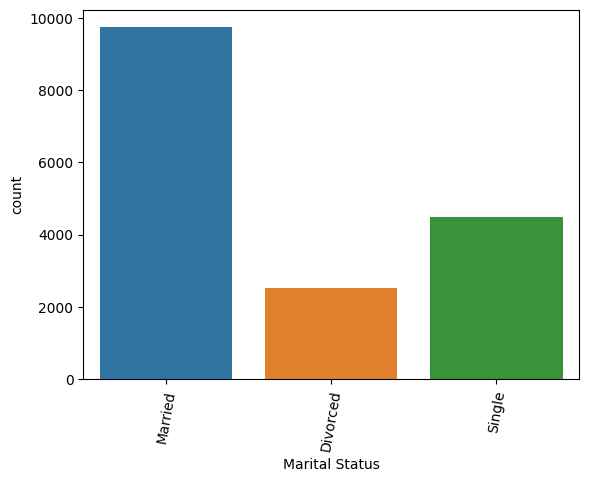

In [ ]:
sns.countplot(data=df_clientes, x="Marital Status", hue="Marital Status");
plt.xticks(rotation=80)
plt.show()

Interpretacion: La mayoria de nuestro clientes estan casados

In [17]:
# Ejemplo: CLV promedio por tipo de tarjeta de fidelidad
df_clientes.groupby("Loyalty Card")["CLV"].mean().sort_values(ascending=False)

Loyalty Card
Aurora    10672.686325
Nova       8045.615995
Star       6741.761372
Name: CLV, dtype: float64

<Axes: xlabel='Loyalty Card', ylabel='CLV'>

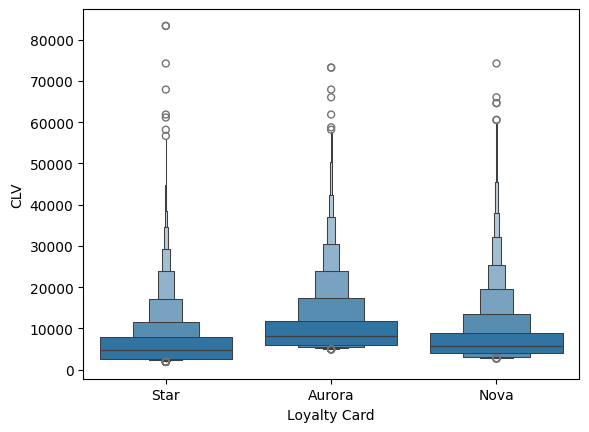

In [ ]:
sns.boxenplot(data=df_clientes, x= "Loyalty Card",y="CLV")

Interpretacion: La mayoria de los clientes tienen la tarjeta star,se deberia hacer mejores promociones en las tarjetas


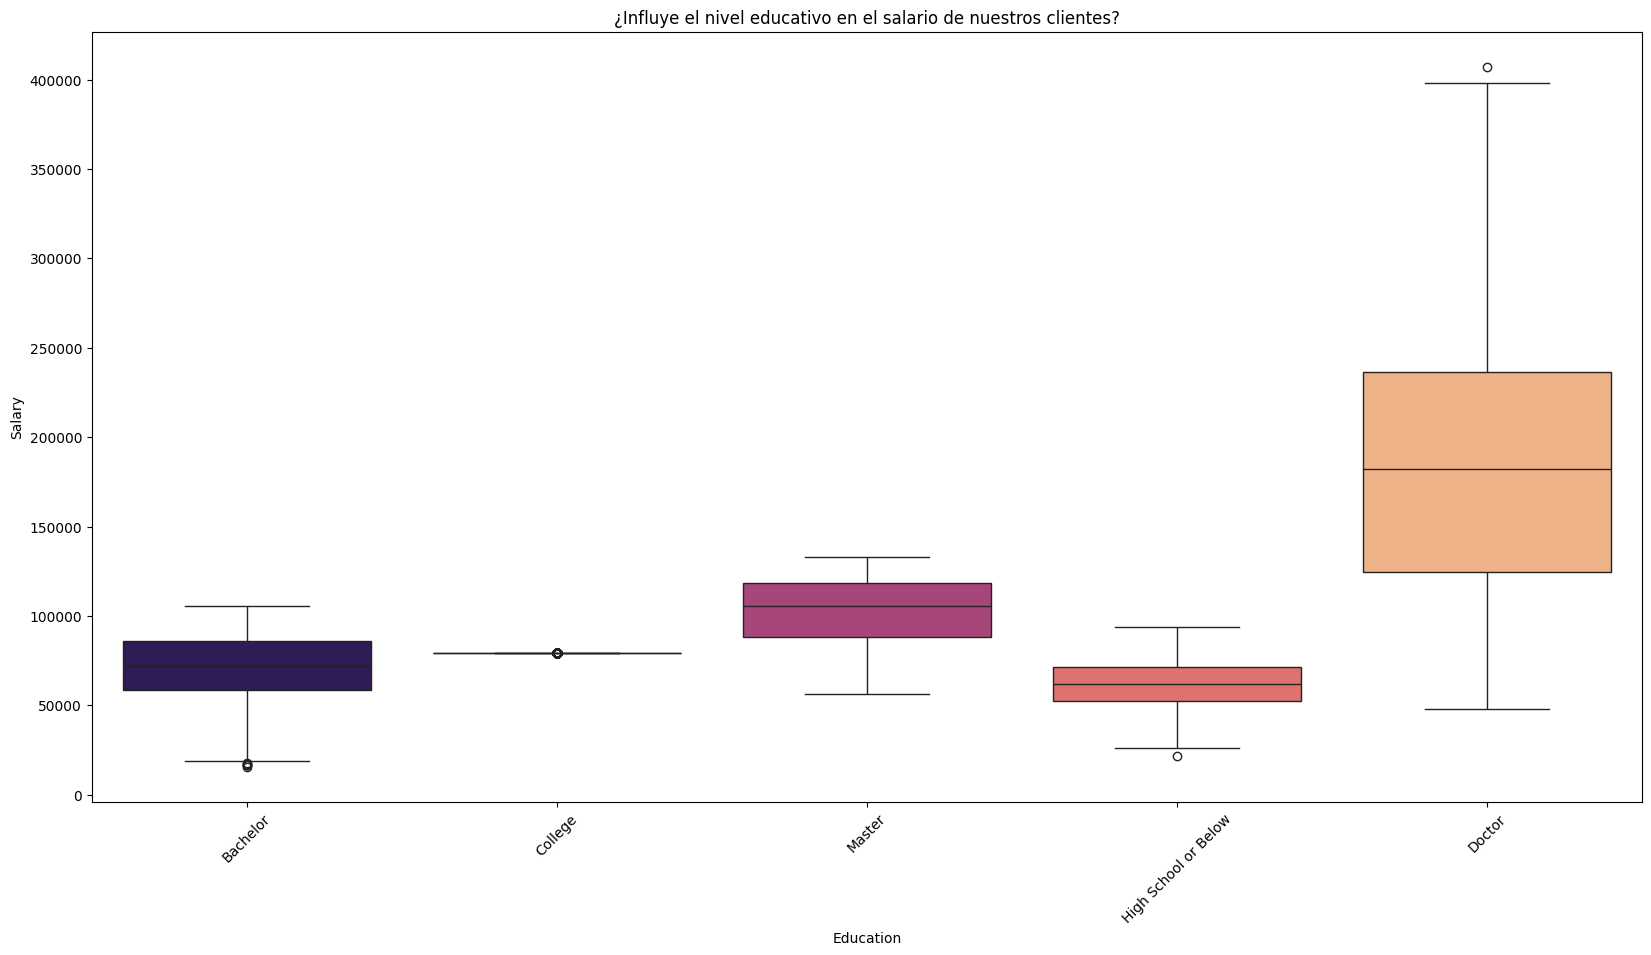

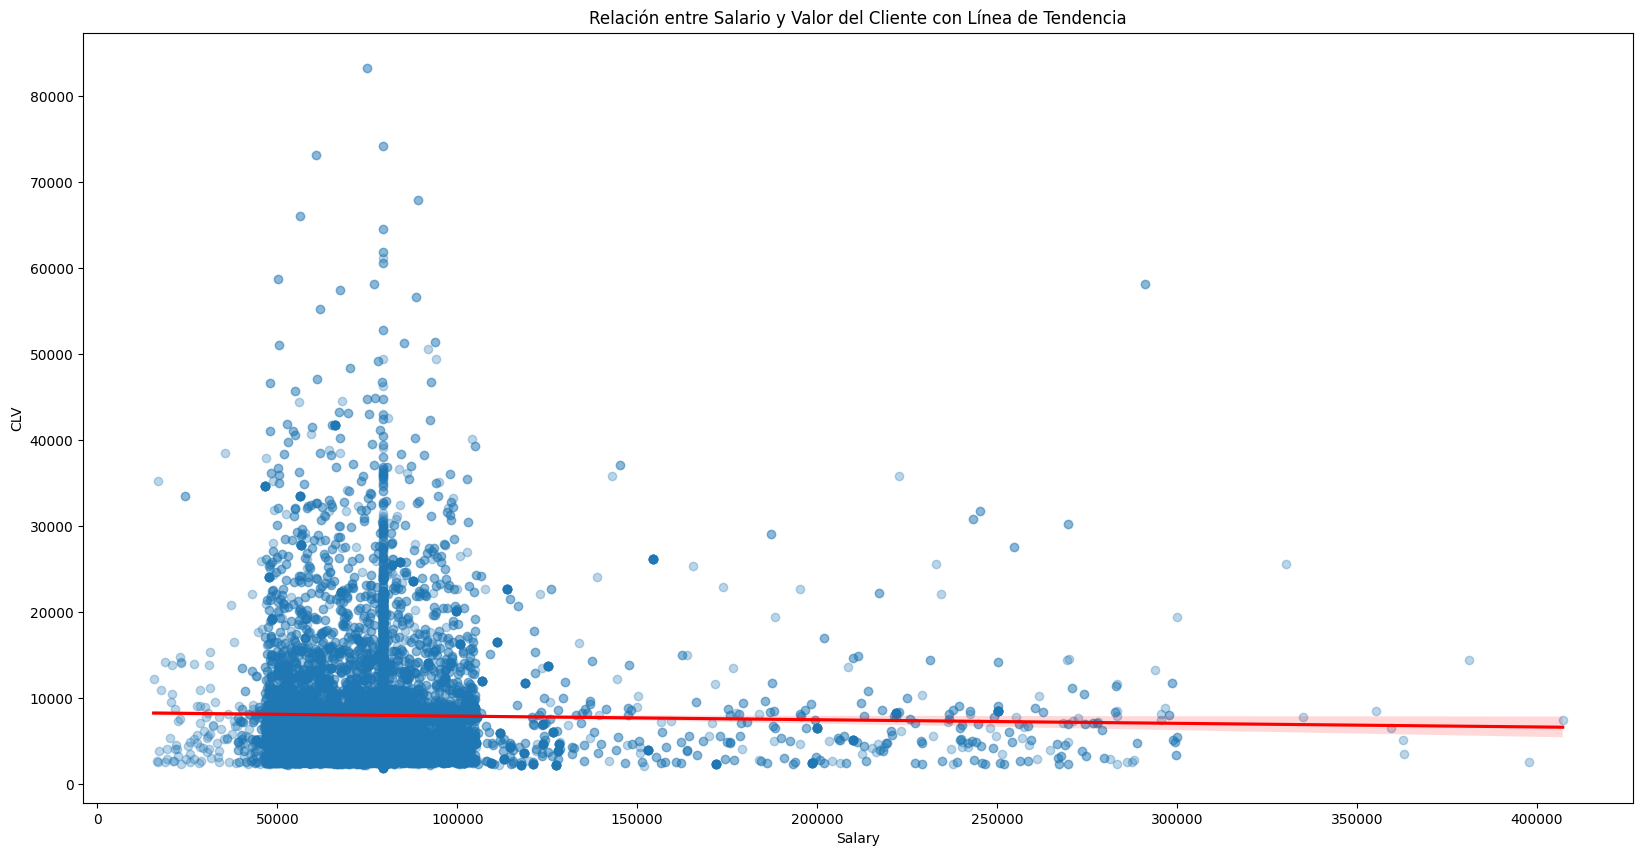

In [29]:
# 1. Comparativa de Salario por Nivel Educativo
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_clientes, x="Education", y="Salary", palette="magma")
plt.title("¿Influye el nivel educativo en el salario de nuestros clientes?")
plt.xticks(rotation=45)
plt.show()

# 2. Relación entre Salario y CLV (¿Los que más ganan son más valiosos?)
# Cambia sns.scatterplot por sns.regplot
plt.figure(figsize=(20, 10))
sns.regplot(data=df_clientes, x="Salary", y="CLV", scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Relación entre Salario y Valor del Cliente con Línea de Tendencia")
plt.show()

Interpretacion: Claramente podemos comprobar como le nivel educativo influye en el nivel salarial de nuestros clientes a mas nivel educativo, mas salario.Y no existe una correlacion fuerte entre el salario y el valor del cliente

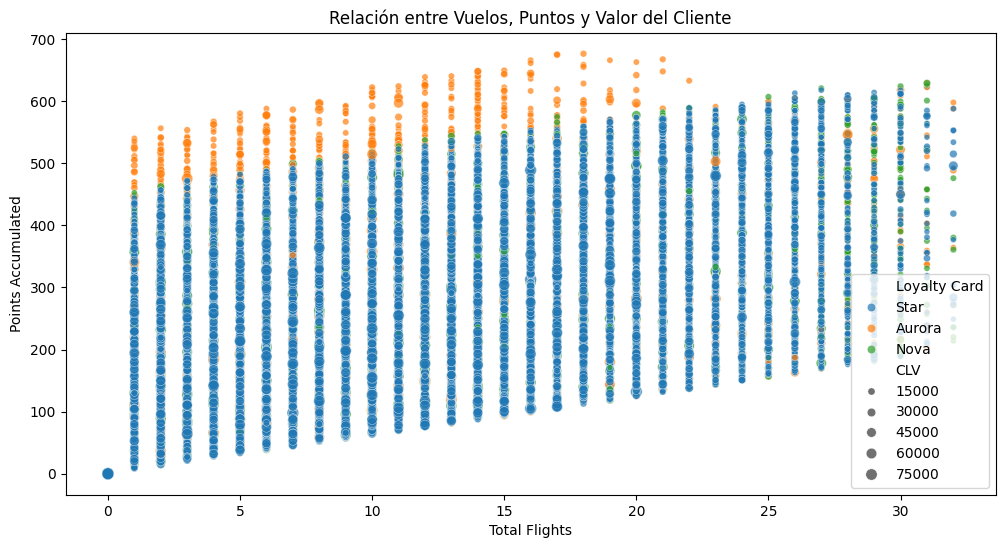

In [59]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_final, x="Total Flights", y="Points Accumulated", hue="Loyalty Card", size="CLV", alpha=0.7)
plt.title("Relación entre Vuelos, Puntos y Valor del Cliente")
plt.show()

Interpretación: Esto confirma que el sistema de puntos funciona perfectamente: a más vuelos reservados, más puntos acumulados. Es una relación casi lineal y lógica
Respecto al salario:Esto es un gran hallazgo. Significa que el sueldo no influye en cuánto vuela el cliente. Tienes clientes con salarios bajos que vuelan muchísimo y clientes ricos que casi no viajan. 
CVL: Esto sugiere que el CLV se calcula con métricas distintas a la frecuencia de vuelo actual



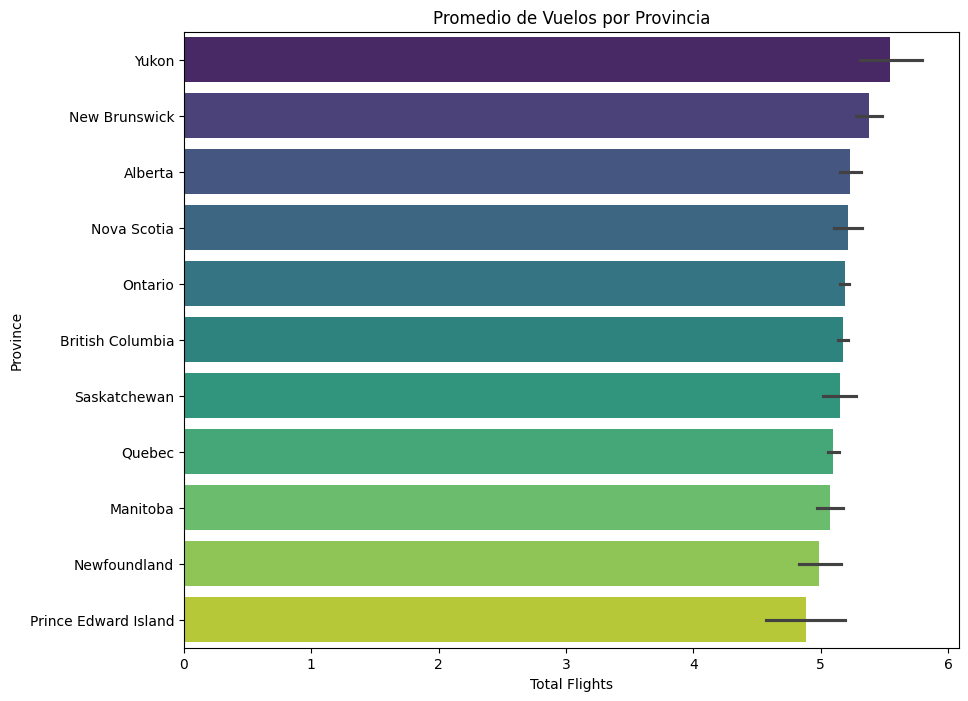

In [62]:
plt.figure(figsize=(10, 8))
# Agrupamos y ordenamos para que la gráfica sea clara
order = df_final.groupby("Province")["Total Flights"].mean().sort_values(ascending=False).index

sns.barplot(data=df_final, y="Province", x="Total Flights", order=order, palette="viridis")
plt.title("Promedio de Vuelos por Provincia")
plt.show()

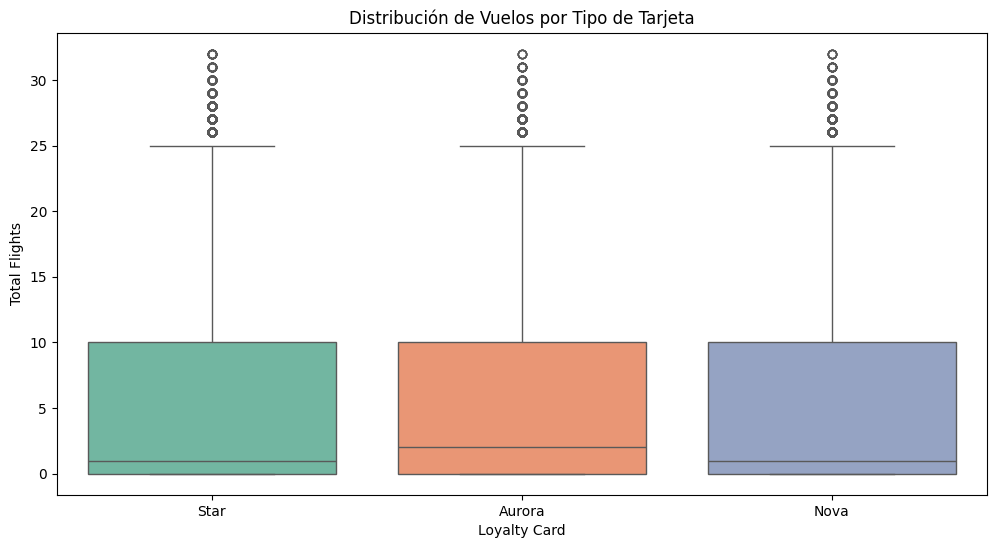

In [61]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_final, x="Loyalty Card", y="Total Flights", palette="Set2")
plt.title("Distribución de Vuelos por Tipo de Tarjeta")
plt.show()

Interpretacion: Las tarjetas estan equilibradas.El programa de lealtad distribuye bien los beneficios